In [2]:
import simpy
import numpy as np
import matplotlib.pyplot as plt

In [10]:
n = 5  #cantidad de robots
cantidad_reparadores = 2  # cantidad de reparadores
media_fallos = 30  # media de tiempo entre fallos 
media_reparacion = 3  # media de tiempo de reparación 
tiempo_simulacion = 1000      # Tiempo total de simulación 
np.random.seed(42)        # Semilla para reproducibilidad
robots_operativos = []    # Eventos de cambio en robots operativos
reparadores_ocupados = []       # Eventos de cambio en reparadores ocupados
tiempo_reparacion = []      # Tiempos de reparación 

def proceso(env, reparadores):
    global count
    while True:
        tiempo_fracaso = np.random.exponential(media_fallos)
        yield env.timeout(tiempo_fracaso)
        
        breakdown_time = env.now
        count -= 1 #si ocurre una falla
        robots_operativos.append((env.now, count))
        
        # Solicitar un reparador
        with reparadores.request() as requisito:

            yield requisito
            ocupado = cantidad_reparadores - reparadores.count
            reparadores_ocupados.append((env.now, ocupado))
            
            repair_duration = np.random.exponential(media_reparacion)
            yield env.timeout(repair_duration)
    
        ocupado = cantidad_reparadores - reparadores.count
        reparadores_ocupados.append((env.now, ocupado))
       
        count += 1
        robots_operativos.append((env.now, count))
        tiempo_reparacion.append(env.now - breakdown_time)

env = simpy.Environment()
reparadores = simpy.Resource(env, capacity=cantidad_reparadores)
count = n  
robots_operativos.append((0, count))  

for _ in range(n):
    env.process(proceso(env, reparadores))

# simulacion
env.run(until=tiempo_simulacion)


In [11]:
# numero medio de robots operativos
robots_operativos.sort(key=lambda x: x[0])
total_operational = 0
prev_time, prev_count = robots_operativos[0]

for time, count in robots_operativos[1:]:
    delta = time - prev_time
    total_operational += prev_count * delta
    prev_time, prev_count = time, count

# Agregar tiempo restante 
delta = tiempo_simulacion - prev_time
total_operational += prev_count * delta
avg_operational = total_operational / tiempo_simulacion

In [ ]:

# tiempo promedio de reparacion
avg_repair_time = np.mean(tiempo_reparacion) if tiempo_reparacion else 0

# porcentaje de tiempo con al menos un reparador inactivo
reparadores_ocupados.sort(key=lambda x: x[0])
idle_time = 0
prev_time, prev_busy = reparadores_ocupados[0]

for time, busy in reparadores_ocupados[1:]:
    delta = time - prev_time
    if prev_busy < cantidad_reparadores:
        idle_time += delta
    prev_time, prev_busy = time, busy

delta = tiempo_simulacion - prev_time
if prev_busy < cantidad_reparadores:
    idle_time += delta

percentage_idle = (idle_time / tiempo_simulacion) * 100

In [13]:
print(f"Número medio de robots operativos: {avg_operational:.2f}")
print(f"Tiempo promedio de reparación: {avg_repair_time:.2f} horas")
print(f"Porcentaje de tiempo con algún operario inactivo: {percentage_idle:.2f}%")

Número medio de robots operativos: 4.61
Tiempo promedio de reparación: 2.74 horas
Porcentaje de tiempo con algún operario inactivo: 34.69%


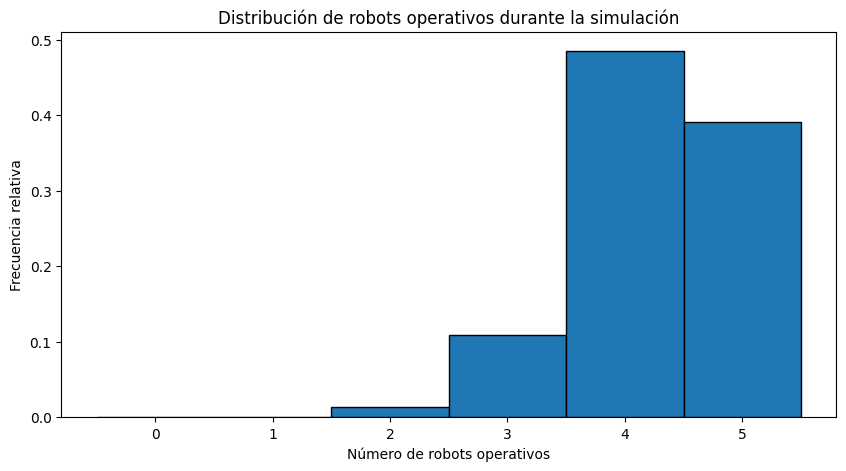

In [14]:
# Distribución de robots operativos
plt.figure(figsize=(10, 5))
plt.hist(
    [count for _, count in robots_operativos],
    bins=np.arange(0, n + 2) - 0.5,
    density=True,
    edgecolor='black'
)
plt.xticks(range(n + 1))
plt.xlabel('Número de robots operativos')
plt.ylabel('Frecuencia relativa')
plt.title('Distribución de robots operativos durante la simulación')
plt.show()

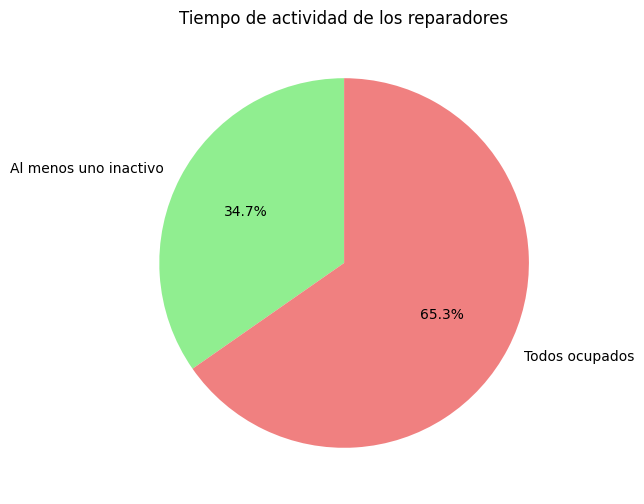

In [15]:
# Tiempo de actividad de los reparadores
plt.figure(figsize=(6, 6))
labels = ['Al menos uno inactivo', 'Todos ocupados']
sizes = [percentage_idle, 100 - percentage_idle]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['lightgreen', 'lightcoral'])
plt.title('Tiempo de actividad de los reparadores')
plt.show()